Было решено отсечь все классы, у которых нет аннотации. Тк даже если нам не нужна аннотация для обучения детекции, мы используем ее для очистки датасета. Также как правило у классов без аннотации было мало данных.

Остается 
Всего классов: 18
Всего изображений: 18992
Среднее фото на класс: 1055.1

но аннотации есть только у 6752 фото. придется смиритьяс с потерей половины датасета

Метрика: macro F1 <br>
Функция потерь: CrossEntropyLoss<br>
WeightedRandomSampler 

In [1]:
import os
import torch
import csv
import cv2
import shutil
import random
import gc

import matplotlib.pyplot as plt
import torch.nn as nn
import torch.optim as optim
import numpy as np

from tqdm import tqdm
from torch.utils.data import DataLoader, WeightedRandomSampler, Dataset, random_split
from sklearn.metrics import f1_score, classification_report 
from sklearn.model_selection import train_test_split
from torchvision import transforms, datasets, models
from pathlib import Path
from PIL import Image
from imagededup.methods import PHash
from collections import defaultdict

In [2]:
!rm -r "/mnt/data/archive/simpsons_cleaned/"
!rm -r "/mnt/data/archive/simpsons_split/"

In [3]:
ANNOTATION_FILE = "/mnt/data/archive/annotation.txt"
ORIGINAL_ROOT = "/mnt/data/archive/simpsons_dataset/"
CLEANED_ROOT = "/mnt/data/archive/simpsons_cleaned/"

THRESHOLD = 10  # Порог pHash
CROP_SIZE = 224


def parse_annotation(path):
    """
    Читает аннотации и группирует по классам.
    Возвращает: {class_name: [{'path': ..., 'bbox': (x1,y1,x2,y2)}, ...]}
    """
    class_groups = defaultdict(list)

    with open(path, "r", encoding="utf-8") as f:
        reader = csv.reader(f)
        for row in reader:
            if len(row) < 6:
                continue

            # Исправляем путь
            img_path = row[0].replace("./characters/", "")
            full_path = os.path.join(ORIGINAL_ROOT, img_path)

            try:
                x1 = int(float(row[1]))
                y1 = int(float(row[2]))
                x2 = int(float(row[3]))
                y2 = int(float(row[4]))
            except:
                continue

            class_name = row[5].strip()

            if os.path.exists(full_path):
                #группируем по персонажам 
                class_groups[class_name].append(
                    {"path": full_path, "bbox": (x1, y1, x2, y2)}
                )

    return class_groups


def crop_character(img_path, bbox, crop_size=224):
    """
    Вырезает персонажа по боксу и ресайзит для сравнения pHash. Оригинальное изображение не меняется
    """
    img = cv2.imread(img_path)
    if img is None:
        return None

    h, w = img.shape[:2]
    x1, y1, x2, y2 = bbox

    # Защита от выхода за границы
    x1, y1 = max(0, x1), max(0, y1)
    x2, y2 = min(w, x2), min(h, y2)

    if x2 <= x1 or y2 <= y1:
        return None

    # Кроп + ресайз для сравнения
    crop = img[y1:y2, x1:x2]
    crop = cv2.resize(crop, (crop_size, crop_size))

    return crop


def find_unique_images(items, class_name, crop_size=224):
    """
    Находит уникальные изображ0ения внутри класса.Возвращает список путей к оригиналам
    """
    # Временная папка для кропов
    temp_dir = f"./temp_crops_{class_name.replace('/', '_')}"
    os.makedirs(temp_dir, exist_ok=True)

    valid_items = []

    # Создаём кропы для сравнения
    for i, item in enumerate(items):
        crop = crop_character(item["path"], item["bbox"], crop_size)
        if crop is not None:
            save_name = f"crop_{i}.jpg"
            save_path = os.path.join(temp_dir, save_name)
            cv2.imwrite(save_path, crop)
            valid_items.append(
                {"original_path": item["path"], "crop_path": save_path, "index": i}
            )

    # пароверка на минимальное количество изображений
    if len(valid_items) < 2:
        shutil.rmtree(temp_dir, ignore_errors=True)  # удаляет временную папку с кропами
        return [item["original_path"] for item in valid_items]

    # запускаем pHash на кропах
    phasher = PHash(verbose=False)
    encodings = phasher.encode_images(image_dir=temp_dir)  #возвращает словарь {имя файла: хеш}
    duplicates = phasher.find_duplicates(encoding_map=encodings, max_distance_threshold=THRESHOLD, scores=False)
    # возвращает оригнал : [{дубли}]

    # Собираем индексы дублей которые будем удалять
    duplicate_indices = set()
    processed = set()

    for img_name, dup_list in duplicates.items():
        if img_name in processed:
            continue

        processed.add(img_name)

        # Оставляем первый  остальные помечаем как дубли
        for dup_name in dup_list:
            if dup_name == "" or dup_name in processed:
                continue
            processed.add(dup_name)

            # Извлекаем индекс из имени файла crop_X.jpg
            try:
                idx = int(dup_name.split("_")[1].split(".")[0])
                duplicate_indices.add(idx)
            except:
                continue

    # Чистим временную папку
    shutil.rmtree(temp_dir, ignore_errors=True)

    # Возвращаем пути к уникальным оригиналам
    unique_paths = [
        item["original_path"]
        for item in valid_items
        if item["index"] not in duplicate_indices
    ]

    return unique_paths


def copy_to_cleaned_dataset(unique_paths, class_name):
    """
    Копирует оригинальные изображения в новую папку.
    Сохраняет структуру папок.
    """
    # Создаём папку класса в очищенном датасете
    dest_class_folder = os.path.join(CLEANED_ROOT, class_name)
    os.makedirs(dest_class_folder, exist_ok=True)

    copied_count = 0
    for orig_path in unique_paths:
        # Имя файла остаётся тем же
        filename = os.path.basename(orig_path)
        dest_path = os.path.join(dest_class_folder, filename)

        # Копируем оригинал
        shutil.copy2(orig_path, dest_path)
        copied_count += 1

    return copied_count


if __name__ == "__main__":

    # создаём корневую папку очищенного датасета
    os.makedirs(CLEANED_ROOT, exist_ok=True)

    groups = parse_annotation(ANNOTATION_FILE)

    total_original = sum(len(items) for items in groups.values())

    # Статистика
    stats = []
    total_unique = 0

    # Обработка каждого класса
    for class_name, items in groups.items():
        # Находим уникальные изображения
        unique_paths = find_unique_images(items, class_name, CROP_SIZE)

        # Копируем в новый датасет
        copied = copy_to_cleaned_dataset(unique_paths, class_name)
        total_unique += copied

        stats.append(
            {
                "class": class_name,
                "original": len(items),
                "unique": copied,
                "removed": len(items) - copied,
            }
        )

2026-04-04 12:19:34,695: INFO Start: Calculating hashes...
2026-04-04 12:19:35,198: INFO End: Calculating hashes!
/home/julia/miniconda3/lib/python3.13/site-packages/imagededup/methods/hashing.py:317: RuntimeWarning: Parameter num_enc_workers has no effect since encodings are already provided
  warnings.warn('Parameter num_enc_workers has no effect since encodings are already provided', RuntimeWarning)
2026-04-04 12:19:35,200: INFO Start: Evaluating hamming distances for getting duplicates
2026-04-04 12:19:35,200: INFO Start: Retrieving duplicates using Cython Brute force algorithm
2026-04-04 12:19:35,343: INFO End: Retrieving duplicates using Cython Brute force algorithm
2026-04-04 12:19:35,344: INFO End: Evaluating hamming distances for getting duplicates
2026-04-04 12:19:35,824: INFO Start: Calculating hashes...
2026-04-04 12:19:36,098: INFO End: Calculating hashes!
2026-04-04 12:19:36,099: INFO Start: Evaluating hamming distances for getting duplicates
2026-04-04 12:19:36,099: INFO

In [4]:
# статистикка

MAIN_DATASET_PATH = "/mnt/data/archive/simpsons_cleaned/"

def count_images_in_folders(base_path):
    stats = {}
    path = Path(base_path)

    if not path.exists():
        print(f"Папка {base_path} не найдена!")
        return stats

    for folder in path.iterdir():
        if folder.is_dir():
            images = [
                f
                for f in folder.iterdir()
                if f.suffix.lower() in [".jpg", ".jpeg", ".png", ".bmp"]
            ]
            stats[folder.name] = len(images)

    return stats


def print_statistics(stats, dataset_name):
    if not stats:
        print("Нет данных для анализа")
        return

    values = list(stats.values())
    total_images = sum(values)
    total_classes = len(stats)
    min_count = min(values)
    max_count = max(values)
    mean_count = sum(values) / len(values)

    min_class = [k for k, v in stats.items() if v == min_count]
    max_class = [k for k, v in stats.items() if v == max_count]

    print(f"Всего классов: {total_classes}")
    print(f"Всего изображений: {total_images}")
    print(f"Среднее фото на класс: {mean_count:.1f}")
    print(f"Минимум фото в классе: {min_count} ({', '.join(min_class)})")
    print(f"Максимум фото в классе: {max_count} ({', '.join(max_class)})")

    for cls, count in sorted(stats.items(), key=lambda x: x[1], reverse=True)[::]:
        print(f"   -{cls}: {count} фото")


if __name__ == "__main__":
    train_stats = count_images_in_folders(MAIN_DATASET_PATH)
    print_statistics(train_stats, "dataset")

Всего классов: 18
Всего изображений: 6489
Среднее фото на класс: 360.5
Минимум фото в классе: 163 (sideshow_bob)
Максимум фото в классе: 624 (charles_montgomery_burns)
   -charles_montgomery_burns: 624 фото
   -homer_simpson: 604 фото
   -abraham_grampa_simpson: 564 фото
   -ned_flanders: 562 фото
   -lisa_simpson: 543 фото
   -marge_simpson: 540 фото
   -bart_simpson: 536 фото
   -principal_skinner: 487 фото
   -krusty_the_clown: 222 фото
   -nelson_muntz: 216 фото
   -kent_brockman: 209 фото
   -moe_szyslak: 208 фото
   -milhouse_van_houten: 204 фото
   -chief_wiggum: 204 фото
   -edna_krabappel: 204 фото
   -apu_nahasapeemapetilon: 202 фото
   -comic_book_guy: 197 фото
   -sideshow_bob: 163 фото


In [5]:
CLEANED_ROOT = "/mnt/data/archive/simpsons_cleaned/"
SPLIT_ROOT = "/mnt/data/archive/simpsons_split/"

TRAIN_RATIO = 0.70
VAL_RATIO = 0.15
TEST_RATIO = 0.15

RANDOM_SEED = 42  

def get_class_images(root_dir):
    """
    Собирает пути к изображениям, сгруппированные по классам {class_name: [path1, path2, ...]}
    """
    class_images = defaultdict(list)

    for class_name in os.listdir(root_dir):
        class_path = os.path.join(root_dir, class_name)
        if not os.path.isdir(class_path):
            continue

        for filename in os.listdir(class_path):
            if filename.lower().endswith((".jpg", ".jpeg", ".png")):
                img_path = os.path.join(class_path, filename)
                class_images[class_name].append(img_path)

    return class_images


def stratified_split(class_images, train_ratio, val_ratio, test_ratio, seed=42):
    """
    Делает стратифицированное разбиение для каждого класса отдельно. Возвращает: {split_name: {class_name: [paths]}}
    """
    splits = {"train": {}, "val": {}, "test": {}}

    random.seed(seed)

    for class_name, images in class_images.items():
        # перемешиваем внутри класса
        shuffled = images.copy()
        random.shuffle(shuffled)

        train_imgs, temp_imgs = train_test_split(
            shuffled,
            train_size=train_ratio,
            random_state=seed,
            shuffle=True,  # на всякий случай
        )

        #  val vs test из оставшихся
        # нормируем пропорции относительно оставшейся части
        val_size = val_ratio / (val_ratio + test_ratio)
        val_imgs, test_imgs = train_test_split(temp_imgs, train_size=val_size, random_state=seed, shuffle=True)

        splits["train"][class_name] = train_imgs
        splits["val"][class_name] = val_imgs
        splits["test"][class_name] = test_imgs

    return splits


def copy_split_images(splits, output_root):
    """
    Копирует изображения в новую структуру папок output_root/{train,val,test}/{class_name}/{filename}
    """
    stats = {}

    for split_name, class_dict in splits.items():
        split_path = os.path.join(output_root, split_name)
        os.makedirs(split_path, exist_ok=True)

        split_stats = {}

        for class_name, img_paths in class_dict.items():
            class_folder = os.path.join(split_path, class_name)
            os.makedirs(class_folder, exist_ok=True)

            for img_path in img_paths:
                filename = os.path.basename(img_path)
                dest_path = os.path.join(class_folder, filename)
                shutil.copy2(img_path, dest_path)

            split_stats[class_name] = len(img_paths)

        stats[split_name] = split_stats
        print(f"{split_name.upper()}: {sum(split_stats.values())} изображений")

    return stats

if __name__ == "__main__":
    class_images = get_class_images(CLEANED_ROOT)
    total_images = sum(len(imgs) for imgs in class_images.values())

    splits = stratified_split(
        class_images, TRAIN_RATIO, VAL_RATIO, TEST_RATIO, seed=RANDOM_SEED
    )

    stats = copy_split_images(splits, SPLIT_ROOT)

TRAIN: 4533 изображений
VAL: 973 изображений
TEST: 983 изображений


In [6]:
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    DEVICE = torch.device("cuda:0")
    torch.backends.cudnn.benchmark = (True)

In [7]:
DATA_ROOT = "/mnt/data/archive/simpsons_split/"
MODEL_PATH = "/mnt/data/archive/best_resnet34_simpsons.pth"

NUM_CLASSES = 18
BATCH_SIZE = 64  
NUM_EPOCHS = 50
LEARNING_RATE = 0.001
PATIENCE = 15

In [8]:
train_transform = transforms.Compose(
    [
        transforms.Resize((224, 224)),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomRotation(20),
        transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2, hue=0.1),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    # среднее и стандартное отклонение для изображений в imagenet
    ]
)

val_transform = transforms.Compose(
    [
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ]
)

train_dataset = datasets.ImageFolder(os.path.join(DATA_ROOT, "train"), transform=train_transform)
val_dataset = datasets.ImageFolder(os.path.join(DATA_ROOT, "val"), transform=val_transform)
test_dataset = datasets.ImageFolder(os.path.join(DATA_ROOT, "test"), transform=val_transform)

# подсчет изображений по классам
class_counts = np.zeros(NUM_CLASSES)
for _, label in train_dataset:
    class_counts[label] += 1

class_weights = 1.0 / class_counts
sample_weights = [class_weights[label] for _, label in train_dataset]
sample_weights = torch.DoubleTensor(sample_weights)

sampler = WeightedRandomSampler(
    weights=sample_weights, num_samples=len(sample_weights), replacement=True
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    sampler=sampler,
    num_workers=4,
    pin_memory=True,
)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)

class_names = train_dataset.classes

print(f"Train batches: {len(train_loader)}, Val batches: {len(val_loader)}")
print(f"Classes: {train_dataset.classes}", {len(train_dataset.classes)})

Train batches: 71, Val batches: 16
Classes: ['abraham_grampa_simpson', 'apu_nahasapeemapetilon', 'bart_simpson', 'charles_montgomery_burns', 'chief_wiggum', 'comic_book_guy', 'edna_krabappel', 'homer_simpson', 'kent_brockman', 'krusty_the_clown', 'lisa_simpson', 'marge_simpson', 'milhouse_van_houten', 'moe_szyslak', 'ned_flanders', 'nelson_muntz', 'principal_skinner', 'sideshow_bob'] {18}


ResNet34

In [9]:
model = models.resnet34(weights=models.ResNet34_Weights.IMAGENET1K_V1)

In [10]:
# заморозить все слои чтобы предотвратить их обновление
for param in model.parameters():
    param.requires_grad = False

# разморозить layer4 + FC чтобы дообучить их на симпсонах
# layer4 потому что симпсоны не очень похожи на ImageNet
for param in model.layer4.parameters():
    param.requires_grad = True

num_features = model.fc.in_features
model.fc = nn.Linear(num_features, NUM_CLASSES)

model = model.to(DEVICE)

criterion = nn.CrossEntropyLoss().to(DEVICE)

optimizer = optim.Adam(
    [
        {
            "params": model.layer4.parameters(),
            "lr": LEARNING_RATE * 0.1,  
        },
        {
            "params": model.fc.parameters(), 
            "lr": LEARNING_RATE
        },
    ],
    weight_decay=1e-4,
)

#todo
#добавить возможность классифицировать другие классы не симпсонов и других симпсонов
#out of domain и добавить нового симпсона

def calculate_macro_f1(predictions, labels):
    """Считает Macro F1-score"""
    return f1_score(labels, predictions, average="macro")


def evaluate(model, loader, device):
    """Оценка модели"""
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in tqdm(loader, desc="Evaluating", leave=False):
            # Перемещаем данные на GPU
            inputs = inputs.to(device, non_blocking=True) 
            labels = labels.to(device, non_blocking=True)

            outputs = model(inputs)
            probs = torch.nn.functional.softmax(outputs, dim=1)
            _, preds = torch.max(probs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return calculate_macro_f1(all_preds, all_labels)

best_val_f1 = 0.0
patience_counter = 0
history = {"train_loss": [], "val_f1": []}


for epoch in range(NUM_EPOCHS):
    print(f"Эпоха {epoch+1}/{NUM_EPOCHS}")
    # train
    model.train()
    running_loss = 0.0 #накопленная сумма потерь за всю эпоху обучения

    for inputs, labels in tqdm(train_loader, desc="Training", leave=False):
        # Перемещаем данные на GPU
        inputs = inputs.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)

        optimizer.zero_grad()

        with torch.set_grad_enabled(True):
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

        running_loss += loss.item() * inputs.size(0)

    epoch_train_loss = running_loss / len(train_dataset)
    # вот из-за двух предыдущих строк получается взвешенное среднее по изобраэениям
    # чтобы компенсировать возможность что последний батч неполный
    history["train_loss"].append(epoch_train_loss)

    # val
    val_f1 = evaluate(model, val_loader, DEVICE)
    history["val_f1"].append(val_f1)

    print(f"Train Loss: {epoch_train_loss:.4f} | Val Macro F1: {val_f1:.4f}")

    # early stop and checkoint

    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        patience_counter = 0
        torch.save(
            {
                "epoch": epoch,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "val_f1": val_f1,
                "class_names": class_names,
            },
            MODEL_PATH,
        )
        print(f"Новая лучшая модель сохранена (F1: {val_f1:.4f})")
    else:
        patience_counter += 1
        print(f" Patience: {patience_counter}/{PATIENCE}")

        if patience_counter >= PATIENCE:
            print(f"\nEarly stopping на эпохе {epoch+1}")
            break

print(f" Лучший Val Macro F1: {best_val_f1:.4f}")

# test

checkpoint = torch.load(MODEL_PATH)
model.load_state_dict(checkpoint["model_state_dict"])

test_f1 = evaluate(model, test_loader, DEVICE)
print(f"Test Macro F1: {test_f1:.4f}")

print("\nClassification Report (Test):")
model.eval()
all_preds = []
all_labels = []
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(DEVICE)
        labels = labels.to(DEVICE)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

print(classification_report(all_labels, all_preds, target_names=class_names, digits=4))

if torch.cuda.is_available():
    torch.cuda.empty_cache()
    gc.collect()

Эпоха 1/50


Train Loss: 1.3845 | Val Macro F1: 0.8159
Новая лучшая модель сохранена (F1: 0.8159)
Эпоха 2/50


Train Loss: 0.3994 | Val Macro F1: 0.8707
Новая лучшая модель сохранена (F1: 0.8707)
Эпоха 3/50


Train Loss: 0.2347 | Val Macro F1: 0.9025
Новая лучшая модель сохранена (F1: 0.9025)
Эпоха 4/50


Train Loss: 0.1820 | Val Macro F1: 0.8994
 Patience: 1/15
Эпоха 5/50


...

Train Loss: 0.0214 | Val Macro F1: 0.9149
 Patience: 6/15
Эпоха 49/50


Train Loss: 0.0178 | Val Macro F1: 0.9213
 Patience: 7/15
Эпоха 50/50


Train Loss: 0.0096 | Val Macro F1: 0.9257
 Patience: 8/15
 Лучший Val Macro F1: 0.9392


Test Macro F1: 0.9380

Classification Report (Test):


                          precision    recall  f1-score   support

  abraham_grampa_simpson     0.9647    0.9647    0.9647        85
  apu_nahasapeemapetilon     0.9118    1.0000    0.9538        31
            bart_simpson     0.9405    0.9753    0.9576        81
charles_montgomery_burns     0.9670    0.9362    0.9514        94
            chief_wiggum     0.9091    0.9677    0.9375        31
          comic_book_guy     0.9355    0.9667    0.9508        30
          edna_krabappel     0.9062    0.9355    0.9206        31
           homer_simpson     0.8842    0.9231    0.9032        91
           kent_brockman     0.9412    1.0000    0.9697        32
        krusty_the_clown     0.9688    0.9118    0.9394        34
            lisa_simpson     1.0000    0.9512    0.9750        82
           marge_simpson     0.9639    0.9877    0.9756        81
     milhouse_van_houten     1.0000    0.9032    0.9492        31
             moe_szyslak     0.8378    0.9688    0.8986        32
         

Out-of-Domain 


--- OOD Analysis без temperature scaling (Threshold: 0.9) ---
Всего проверено: 38
Распознано как OOD (неизвестные): 24 (63.16%).
Распознано как известные: 14 (36.84%).


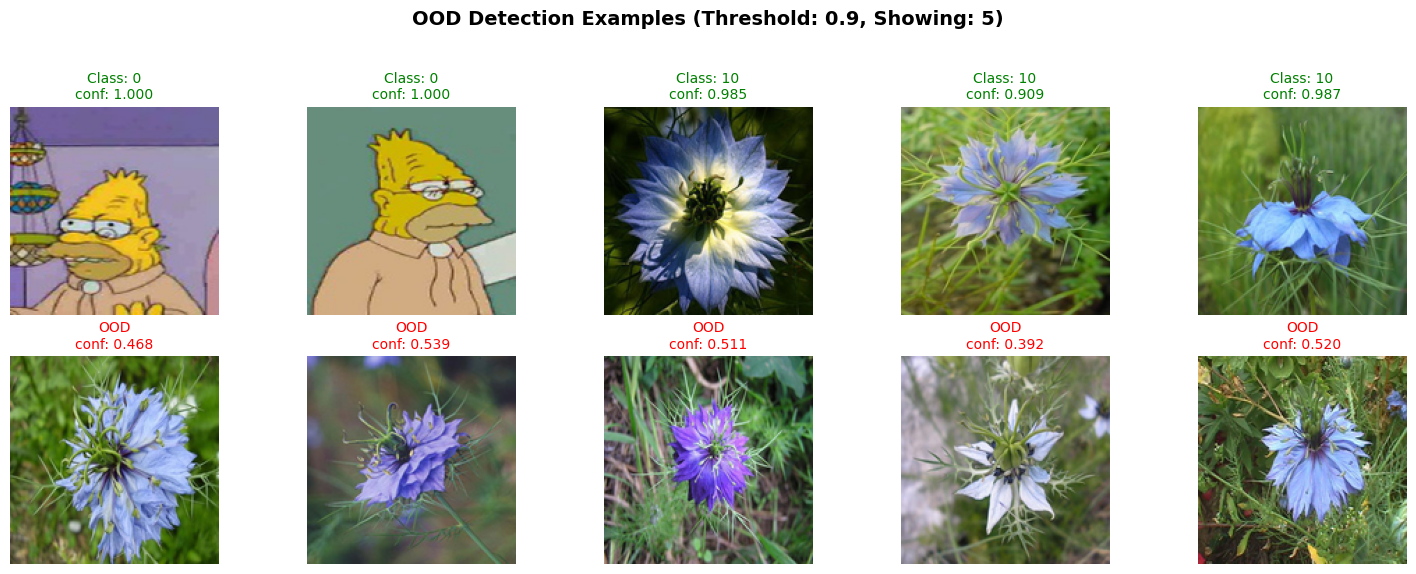

In [11]:
def visualize_ood_examples(in_domain, ood, threshold, num_examples=3):

    n_in = min(len(in_domain), num_examples)
    n_ood = min(len(ood), num_examples)

    if n_in == 0 and n_ood == 0:
        print("Нет примеров для визуализации")
        return

    max_cols = max(n_in, n_ood)
    fig, axes = plt.subplots(2, max_cols, figsize=(max_cols * 3, 6))
    fig.suptitle(
        f"OOD Detection Examples (Threshold: {threshold}, Showing: {num_examples})",
        fontsize=14,
        fontweight="bold",
    )

    if max_cols == 1:
        axes = axes.reshape(-1, 1)

    # сверху примеры которые модель приняла за Симпсонов
    for i in range(max_cols):
        ax = axes[0, i]
        if i < n_in:
            img_path, conf, pred_idx = in_domain[i] 
            try:
                img = Image.open(img_path).convert("RGB")
                img = img.resize((150, 150), Image.Resampling.LANCZOS)
                ax.imshow(img)
                ax.set_title(
                    f"Class: {pred_idx}\nconf: {conf:.3f}", fontsize=10, color="green"
                )
                ax.axis("off")
            except Exception as e:
                ax.text(0.5, 0.5, f"Error\n{e}", ha="center", va="center")
                ax.axis("off")
        else:
            ax.axis("off")

    axes[0, 0].set_ylabel(
        f'Принято как "Симпсон" (n={len(in_domain)})',
        fontsize=12,
        fontweight="bold",
        color="green",
    )

    # снизу примеры которые модель отвергла как OOD
    for i in range(max_cols):
        ax = axes[1, i]
        if i < n_ood:
            img_path, conf, pred_idx = ood[i]
            try:
                img = Image.open(img_path).convert("RGB")
                img = img.resize((150, 150), Image.Resampling.LANCZOS)
                ax.imshow(img)
                ax.set_title(f"OOD\nconf: {conf:.3f}", fontsize=10, color="red")
                ax.axis("off")
            except Exception as e:
                ax.text(0.5, 0.5, f"Error\n{e}", ha="center", va="center")
                ax.axis("off")
        else:
            ax.axis("off")

    axes[1, 0].set_ylabel(
        f"Отвергнуто как OOD (n={len(ood)})",
        fontsize=12,
        fontweight="bold",
        color="red",
    )

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

def evaluate_with_ood_threshold(model, loader, device, threshold=0.8, visualize=True, num_examples=2):
    model.eval()

    ood_images = []  # (img_path, confidence, predicted_class_idx)
    in_domain_images = []
    confidences = []

    with torch.no_grad():
        for inputs, labels, img_paths in loader:
            inputs = inputs.to(device, non_blocking=True)

            outputs = model(inputs)
            probs = torch.softmax(outputs, dim=1)
            max_prob, preds = torch.max(probs, 1)

            for i, conf in enumerate(max_prob):
                conf_val = conf.item()
                pred_idx = preds[i].item()
                confidences.append(conf_val)

                img_info = (img_paths[i], conf_val, pred_idx)

                if conf_val < threshold:
                    ood_images.append(img_info)
                else:
                    in_domain_images.append(img_info)

    total = len(confidences)
    ood_count = len(ood_images)
    ood_rate = ood_count / total if total > 0 else 0
    avg_conf = sum(confidences) / len(confidences) if confidences else 0

    print(f"\n--- OOD Analysis без temperature scaling (Threshold: {threshold}) ---")
    print(f"Всего проверено: {total}")
    print(f"Распознано как OOD (неизвестные): {ood_count} ({ood_rate*100:.2f}%).")
    print(f"Распознано как известные: {total - ood_count} ({(1-ood_rate)*100:.2f}%).")
    
    if visualize and (ood_images or in_domain_images):
        visualize_ood_examples(in_domain_images, ood_images, threshold, num_examples)

    return ood_rate, avg_conf

class ImageFolderWithPaths(datasets.ImageFolder):
    """Расширяет ImageFolder, чтобы возвращать пути к файлам"""

    def __getitem__(self, index):
        sample, target = super().__getitem__(index)
        path = self.imgs[index][0]
        return sample, target, path

ood_dataset = ImageFolderWithPaths("/mnt/data/archive/ood_test/", transform=val_transform,)
ood_loader = DataLoader(ood_dataset, batch_size=8, shuffle=False, num_workers=2)

ood_rate, avg_conf = evaluate_with_ood_threshold(
    model=model,  
    loader=ood_loader,  
    device=DEVICE,  
    threshold=0.9,  
    visualize=True,  
    num_examples=5, 
)


--- OOD Analysis с temperature scaling на фиксированной температуре (Threshold: 0.7) ---
Всего проверено: 38
Распознано как OOD (неизвестные): 32 (84.21%).
Распознано как известные: 6 (15.79%).


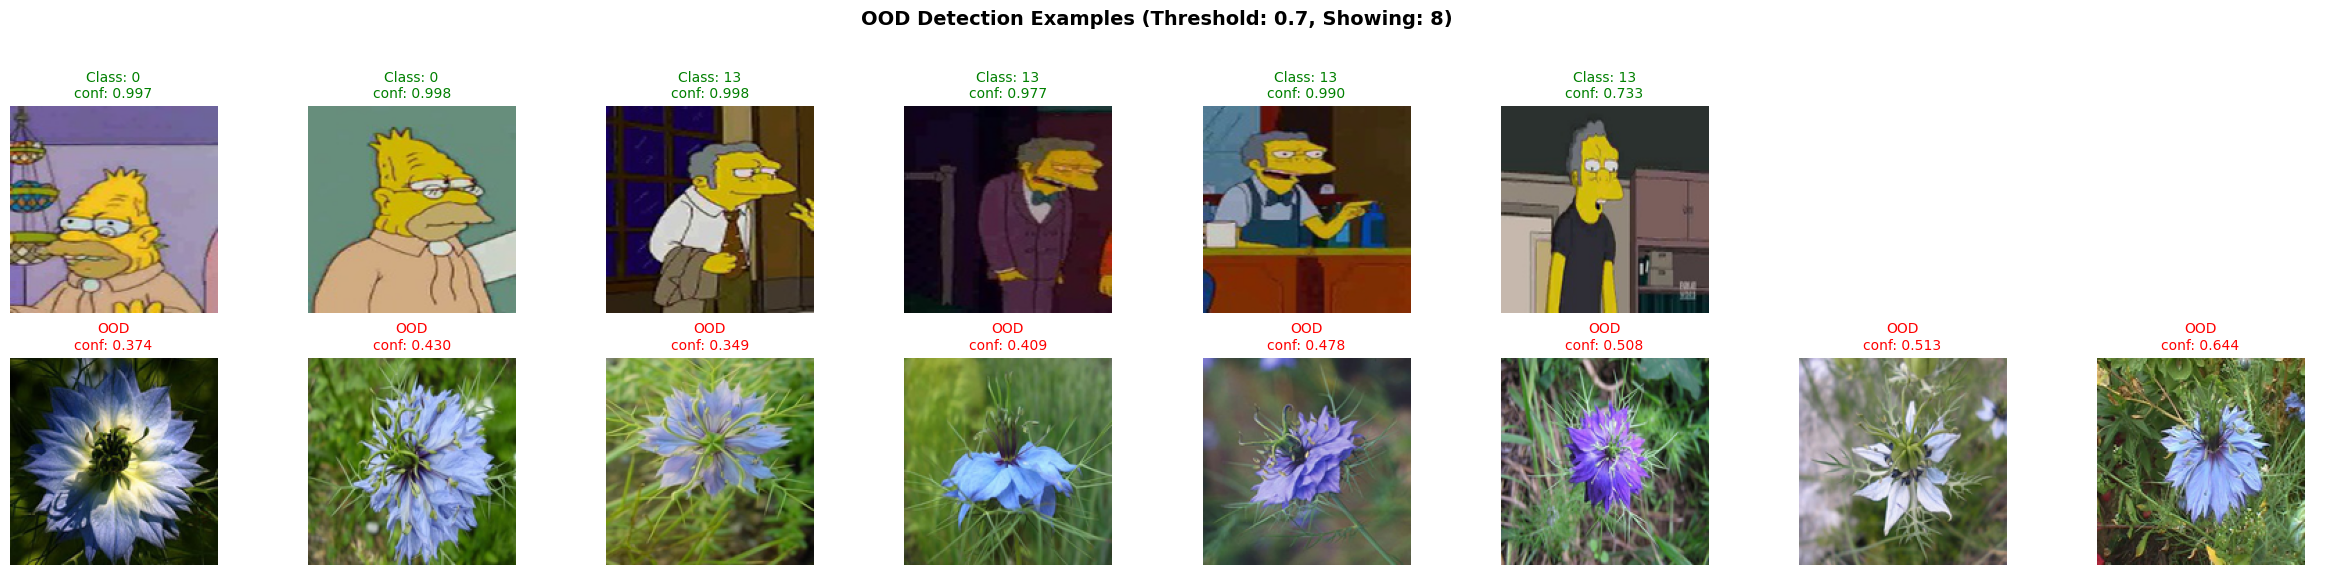

In [20]:
def visualize_ood_examples(in_domain, ood, threshold, num_examples=3):

    n_in = min(len(in_domain), num_examples)
    n_ood = min(len(ood), num_examples)

    if n_in == 0 and n_ood == 0:
        print("Нет примеров для визуализации")
        return

    max_cols = max(n_in, n_ood)
    fig, axes = plt.subplots(2, max_cols, figsize=(max_cols * 3, 6))
    fig.suptitle(
        f"OOD Detection Examples (Threshold: {threshold}, Showing: {num_examples})",
        fontsize=14,
        fontweight="bold",
    )

    if max_cols == 1:
        axes = axes.reshape(-1, 1)

    # сверху примеры которые модель приняла за Симпсонов
    for i in range(max_cols):
        ax = axes[0, i]
        if i < n_in:
            img_path, conf, pred_idx = in_domain[i]
            try:
                img = Image.open(img_path).convert("RGB")
                img = img.resize((150, 150), Image.Resampling.LANCZOS)
                ax.imshow(img)
                ax.set_title(
                    f"Class: {pred_idx}\nconf: {conf:.3f}", fontsize=10, color="green"
                )
                ax.axis("off")
            except Exception as e:
                ax.text(0.5, 0.5, f"Error\n{e}", ha="center", va="center")
                ax.axis("off")
        else:
            ax.axis("off")

    axes[0, 0].set_ylabel(
        f'Принято как "Симпсон" (n={len(in_domain)})',
        fontsize=12,
        fontweight="bold",
        color="green",
    )

    # снизу примеры которые модель отвергла как OOD
    for i in range(max_cols):
        ax = axes[1, i]
        if i < n_ood:
            img_path, conf, pred_idx = ood[i]
            try:
                img = Image.open(img_path).convert("RGB")
                img = img.resize((150, 150), Image.Resampling.LANCZOS)
                ax.imshow(img)
                ax.set_title(f"OOD\nconf: {conf:.3f}", fontsize=10, color="red")
                ax.axis("off")
            except Exception as e:
                ax.text(0.5, 0.5, f"Error\n{e}", ha="center", va="center")
                ax.axis("off")
        else:
            ax.axis("off")

    axes[1, 0].set_ylabel(
        f"Отвергнуто как OOD (n={len(ood)})",
        fontsize=12,
        fontweight="bold",
        color="red",
    )

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()


def evaluate_with_ood_threshold(
    model, loader, device, threshold=0.8, visualize=True, num_examples=2
):
    model.eval()

    ood_images = []  # (img_path, confidence, predicted_class_idx)
    in_domain_images = []
    confidences = []

    with torch.no_grad():
        for inputs, labels, img_paths in loader:
            inputs = inputs.to(device, non_blocking=True)

            outputs = model(inputs)
            # вариант с temperature scaling
            scaled_logits = outputs / 2.0  
            probs = torch.softmax(scaled_logits, dim=1)
            max_prob, preds = torch.max(probs, 1)

            for i, conf in enumerate(max_prob):
                conf_val = conf.item()
                pred_idx = preds[i].item()
                confidences.append(conf_val)

                img_info = (img_paths[i], conf_val, pred_idx)

                if conf_val < threshold:
                    ood_images.append(img_info)
                else:
                    in_domain_images.append(img_info)

    total = len(confidences)
    ood_count = len(ood_images)
    ood_rate = ood_count / total if total > 0 else 0
    avg_conf = sum(confidences) / len(confidences) if confidences else 0

    print(f"\n--- OOD Analysis с temperature scaling на фиксированной температуре (Threshold: {threshold}) ---")
    print(f"Всего проверено: {total}")
    print(f"Распознано как OOD (неизвестные): {ood_count} ({ood_rate*100:.2f}%).")
    print(f"Распознано как известные: {total - ood_count} ({(1-ood_rate)*100:.2f}%).")

    if visualize and (ood_images or in_domain_images):
        visualize_ood_examples(in_domain_images, ood_images, threshold, num_examples)

    return ood_rate, avg_conf


class ImageFolderWithPaths(datasets.ImageFolder):
    """Расширяет ImageFolder, чтобы возвращать пути к файлам"""

    def __getitem__(self, index):
        sample, target = super().__getitem__(index)
        path = self.imgs[index][0]
        return sample, target, path


ood_dataset = ImageFolderWithPaths(
    "/mnt/data/archive/ood_test/",
    transform=val_transform,
)
ood_loader = DataLoader(ood_dataset, batch_size=8, shuffle=False, num_workers=2)

ood_rate, avg_conf = evaluate_with_ood_threshold(
    model=model,
    loader=ood_loader,
    device=DEVICE,
    threshold=0.7,
    visualize=True,
    num_examples=8,
)

Добавление нового класса

In [13]:
OLD_DATA_ROOT = "/mnt/data/archive/simpsons_split/train/"
NEW_CLASS_ROOT = "/mnt/data/archive/new_class/"
NEW_CLASS_NAME = "lenny_leonard"

def add_new_character_class(model, class_names, device, new_class_name):
    old_num_classes = len(class_names)
    new_num_classes = old_num_classes + 1

    # Сохраняем старые веса
    old_fc_weight = model.fc.weight.data.clone()
    old_fc_bias = model.fc.bias.data.clone()

    # Создаем новый слой
    in_features = model.fc.in_features
    model.fc = nn.Linear(in_features, new_num_classes).to(device)

    # Переносим старые веса
    with torch.no_grad():
        model.fc.weight[:old_num_classes, :] = old_fc_weight
        model.fc.bias[:old_num_classes] = old_fc_bias
        # Инициализируем веса нового класса нулями 
        model.fc.weight[old_num_classes, :] = 0
        model.fc.bias[old_num_classes] = 0

    new_class_names = class_names + [new_class_name]
    print(f"Новый класс будет под индексом {old_num_classes}: {new_class_name}")

    for param in model.parameters():
        param.requires_grad = False
    for param in model.layer4.parameters():
        param.requires_grad = True
    for param in model.fc.parameters():
        param.requires_grad = True

    return model, new_class_names


class OffsetDataset(Dataset):
    """Обёртка для сдвига лейблов"""

    def __init__(self, dataset, offset):
        self.dataset = dataset
        self.offset = offset

    def __getitem__(self, index):
        img, label = self.dataset[index]
        return img, label + self.offset

    def __len__(self):
        return len(self.dataset)


def create_mixed_loader_with_val(
    old_root, new_root, transform, batch_size=32, val_ratio=0.2
):
    old_dataset = datasets.ImageFolder(old_root, transform=transform)
    new_dataset = datasets.ImageFolder(new_root, transform=transform)

    # сдвиг лейблы нового датасета на количество старых классов
    offset_dataset = OffsetDataset(new_dataset, offset=len(old_dataset.classes))

    subset_size = int(len(old_dataset) * 0.2)
    indices = torch.randperm(len(old_dataset))[:subset_size]
    old_subset = torch.utils.data.Subset(old_dataset, indices)

    combined_dataset = torch.utils.data.ConcatDataset([old_subset, offset_dataset])

    val_size = int(len(combined_dataset) * val_ratio)
    train_size = len(combined_dataset) - val_size
    train_dataset, val_dataset = random_split(combined_dataset, [train_size, val_size])

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

    print(f"Train: {len(train_dataset)}, Val: {len(val_dataset)}")
    return train_loader, val_loader


checkpoint = torch.load(MODEL_PATH, map_location=DEVICE)
model.load_state_dict(checkpoint["model_state_dict"])
model = model.to(DEVICE)

model, updated_class_names = add_new_character_class(
    model, class_names, DEVICE, NEW_CLASS_NAME
)

train_loader, val_loader = create_mixed_loader_with_val(
    OLD_DATA_ROOT, NEW_CLASS_ROOT, train_transform, batch_size=32, val_ratio=0.2
)

optimizer_finetune = optim.Adam(
    [
        {"params": model.layer4.parameters(), "lr": 0.0001}, 
        {"params": model.fc.parameters(), "lr": 0.0001},  
    ],
    weight_decay=1e-4,
)
criterion = nn.CrossEntropyLoss().to(DEVICE)

patience = 10
patience_counter = 0
best_model_state = None
best_val_f1 = 0 

for epoch in range(50):
    # Train
    model.train()
    train_loss = 0.0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)

        optimizer_finetune.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer_finetune.step()

        train_loss += loss.item()

    train_loss /= len(train_loader)

    # Validation
    model.eval()
    val_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item()

            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    val_loss /= len(val_loader)
    val_f1 = f1_score(all_labels, all_preds, average='macro')

    print(
        f"Эпоха {epoch+1}/50, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}, Val F1: {val_f1:.4f}"
    )

    # Early stopping
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        patience_counter = 0
        best_model_state = model.state_dict().copy() 
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"Early stopping на эпохе {epoch+1}")
            break

if best_model_state is not None:
    model.load_state_dict(best_model_state)

NEW_MODEL_PATH = "/mnt/data/archive/best_resnet34_simpsons_19classes.pth"
torch.save(
    {
        "model_state_dict": model.state_dict(),
        "class_names": updated_class_names,
        "num_classes": len(updated_class_names),
    },
    NEW_MODEL_PATH,
)

test_dataset = datasets.ImageFolder(NEW_CLASS_ROOT, transform=val_transform)
test_loader = DataLoader(test_dataset, batch_size=8, shuffle=False)

model.eval()
correct_new_class = 0
total_new_class = 0
class_predictions = {i: 0 for i in range(len(updated_class_names))}

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
        outputs = model(inputs)
        probs = torch.nn.functional.softmax(outputs, dim=1)
        _, preds = torch.max(probs, 1)

        for pred, label in zip(preds.cpu().numpy(), labels.cpu().numpy()):
            class_predictions[pred] += 1
            if pred == label:
                correct_new_class += 1
            total_new_class += 1


Новый класс будет под индексом 18: lenny_leonard
Train: 973, Val: 243
Эпоха 1/50, Train Loss: 0.8255, Val Loss: 0.4350, Val F1: 0.9380
Эпоха 2/50, Train Loss: 0.2474, Val Loss: 0.1432, Val F1: 0.9380
Эпоха 3/50, Train Loss: 0.1095, Val Loss: 0.0807, Val F1: 0.9380
Эпоха 4/50, Train Loss: 0.0708, Val Loss: 0.0453, Val F1: 0.9380
Эпоха 5/50, Train Loss: 0.0397, Val Loss: 0.0466, Val F1: 0.9380
Эпоха 6/50, Train Loss: 0.0587, Val Loss: 0.0658, Val F1: 0.9380
Эпоха 7/50, Train Loss: 0.0314, Val Loss: 0.0551, Val F1: 0.9380
Эпоха 8/50, Train Loss: 0.0363, Val Loss: 0.0623, Val F1: 0.9380
Эпоха 9/50, Train Loss: 0.0359, Val Loss: 0.0346, Val F1: 0.9380
Эпоха 10/50, Train Loss: 0.0316, Val Loss: 0.0356, Val F1: 0.9380
Эпоха 11/50, Train Loss: 0.0229, Val Loss: 0.0502, Val F1: 0.9380
Early stopping на эпохе 11


In [22]:
def predict_single_image(model, img_path, transform, class_names, device):
    model.eval()
    from PIL import Image

    img = Image.open(img_path).convert("RGB")
    img_t = transform(img).unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = model(img_t)
        probs = torch.nn.functional.softmax(outputs, dim=1)
        max_prob, pred = torch.max(probs, 1)
        return class_names[pred.item()], max_prob.item()

cls, conf = predict_single_image(
    model,
    "/mnt/data/archive/new_class/lenny_leonard/pic_0056.jpg",
    val_transform,
    updated_class_names,
    DEVICE,
)
print(f"Предсказание: {cls}, Уверенность: {conf:.4f}")

cls, conf = predict_single_image(
    model,
    "/mnt/data/archive/simpsons_cleaned/sideshow_bob/pic_0000.jpg",
    val_transform,
    updated_class_names,
    DEVICE,
)
print(f"Предсказание: {cls}, Уверенность: {conf:.4f}")

Предсказание: lenny_leonard, Уверенность: 0.9809
Предсказание: sideshow_bob, Уверенность: 0.9993
